In [1]:
"""
IMPORTANT: Run the following command in the terminal to install dggrid

conda install -c conda-forge dggrid

"""

'\nIMPORTANT: Run the following command in the terminal to install dggrid\n\nconda install -c conda-forge dggrid\n\n'

In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import json
from dotenv import load_dotenv 

load_dotenv("app.properties")     

True

In [4]:
"""
============================================================================

Setup to quantize a raster into DGGS ISEA7H data

============================================================================
"""
import os
import warnings
from typing import Any

import datetime
import json
import dggrid4py
import geopandas as gpd
import numpy as np
import shapely
import rasterio as rio
from dggrid4py.auxlat import geoseries_to_authalic, geoseries_to_geodetic
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling

from vgrid.conversion.raster2dggs.raster2dggrid import get_nearest_dggrid_resolution
from vgrid.utils.geometry import geodesic_dggs_metrics
from vgrid.utils.io import (
    convert_to_output_format,
    validate_dggrid_type,
    validate_dggrid_resolution,
)
import shutil

"""
============================================================================

DGGRS library

============================================================================
"""
dggrid_exec = shutil.which("dggrid")
dggrid_instance = dggrid4py.DGGRIDv8(
    executable=dggrid_exec,
    working_dir='.',
    capture_logs=False,
    has_gdal=True,
    tmp_geo_out_legacy=False,
    silent=True,
    debug=False,
)

"""
============================================================================

Function to convert raster into DGGS data

============================================================================
"""

def raster_reproject(raster_path: os.PathLike, dst_crs: str = "EPSG:4326") -> os.PathLike:
    reproject_name, reproject_ext = os.path.splitext(os.path.basename(raster_path))
    reproject_name = f"{reproject_name}_{dst_crs.replace(':', '')}"
    reproject_path = os.path.join(os.path.dirname(raster_path), f"{reproject_name}{reproject_ext}")
    if os.path.isfile(reproject_path):
        return reproject_path

    with rio.open(raster_path) as src:
        if src.crs == dst_crs:
            return raster_path

        transform, width, height = calculate_default_transform(src.crs, dst_crs, src.width, src.height, *src.bounds)
        dst_meta = src.meta.copy()
        dst_meta.update({
            "crs": dst_crs,
            "transform": transform,
            "width": width,
            "height": height,
            # Cloud-Optimized GeoTIFF (COG) creation options
            "interleave": "pixel",
            "compress": "DEFLATE",
            "tiled": True,
            "blockxsize": 512,
            "blockysize": 512,
        })
        with rio.open(reproject_path, 'w', **dst_meta) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rio.band(src, i),
                    destination=rio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest,
                )
    return reproject_path


def build_overviews(raster_path: os.PathLike, overviews: list[int] = None):
    overviews = overviews or [2, 4, 8, 16, 32]
    with rio.open(raster_path, "r+") as src:
        src.build_overviews(overviews, Resampling.nearest)
        src.update_tags(ns="rio_overview", resampling="nearest")


def raster2dggs_custom(
    dggrid_instance: "dggrid4py.DGGRID",
    dggs_type: str,
    raster_path: os.PathLike,
    resolution: int | None = None,
    output_format: str = "gpd",
    output_cell_path: str | None = None,  # raster path by default if not specified
    output_cell_data: bool = True,
    extra_properties: dict[str, Any] = None,
    dggs_zones_path: os.PathLike | None = None,
    **output_kwargs,
) -> gpd.GeoDataFrame | None:

    dggs_type = validate_dggrid_type(dggs_type)
    raster_path = raster_reproject(raster_path)  # pre-reproject to reduce time for each iter of dggrid
    output_cell_path = output_cell_path or os.path.dirname(raster_path)
    os.makedirs(output_cell_path, exist_ok=True)
    extra_properties = extra_properties or {}

    # Auto-select resolution if not provided
    if resolution is None:
        cell_size, resolution = get_nearest_dggrid_resolution(dggrid_instance, dggs_type, raster_path)
        print(f"Cell size: {cell_size} m2")
        print(f"Nearest {dggs_type.upper()} resolution determined: {resolution}")
    else:
        resolution = validate_dggrid_resolution(dggs_type, resolution)

    if output_cell_data:
        build_overviews(raster_path)

    # Open the raster file to get metadata and data
    src = rio.open(raster_path)

    # collect cells
    # NOTE:
    #   Although we can reduce the grid area with raster/DGGS/AOI intersection,
    #   calculating the DGGRS zones is what takes the longest time (especially at high resolutions).
    #   Therefore, reuse a cached DGGRS of all candidates over the entire AOI,
    #   and ignore empty cells data due to no overlapping raster pixels.
    #   This approach as the added advantage that, due to static DGGS/AOI geometry,
    #   we can avoid re-download of the raster data (to save space) by directly iterating
    #   over all DGGS resolutions for one raster at a time.
    #   When using the cached 'dggs_zones_path' approach with constant DGGS zones over AOI,
    #   it is faster to compute the all resolutions over the STAC Item to take advantage
    #   of the cache on next iterations, even if more zones are computed than needed.
    #   If instead using the raster-specific extent to reduce the AOI by their intersection,
    #   then each iteration must do its own operation (no cache). This is negligible at low
    #   resolutions, but becomes significant at high resolutions.
    raster_geom = shapely.geometry.box(*list(src.bounds))
    
    if dggs_zones_path and os.path.isfile(dggs_zones_path):
        cells = read_vector_file(dggs_zones_path)
        aoi_geom = raster_geom  # only the overall AOI
    else:
        if not dggs_zones_path:
            # previous approach that recomputes for each raster/DGGS/AOI intersection
            aoi_geom = raster_geom
        else:
            aoi_geom = raster_geom  # only the overall AOI
        if aoi_geom.geom_type == "GeometryCollection":
            aoi_geom = shapely.unary_union([g for g in aoi_geom.geoms if g.geom_type in ["Polygon", "MultiPolygon"]])
        if aoi_geom.is_empty:
            raise ValueError("Invalid empty AOI geometry.")
        if aoi_geom.geom_type != "Polygon":
            raise ValueError(f"Invalid AOI geometry type: {aoi_geom.geom_type}.")
        aoi_geom = geoseries_to_authalic(gpd.GeoSeries(aoi_geom))[0]
        cells = dggrid_instance.grid_cell_polygons_for_extent(
            dggs_type,
            resolution=resolution,
            clip_geom=aoi_geom,
            **output_kwargs
        )
        cells.geometry = geoseries_to_geodetic(cells.geometry)
        if dggs_zones_path:  # cache for next iteration
            save_vector_file(cells, dggs_zones_path)
    cell_count = len(cells)
    print(f"Matched cells: {cell_count} (res={resolution}) in {aoi_geom}")

    properties = []

    # Collect band values during the pixel scan, storing the first sample per DGGRID cell
    for cell in cells.itertuples(index=False):
        cell_id = cell.name if hasattr(cell, "name") else cell.global_id
        cell_geom = cell.geometry
        try:
            cell_data, cell_transform = mask(src, [cell_geom], crop=True)
        except ValueError:
            continue  # skip empty cells (geom does not overlap raster)
        cell_meta = src.meta.copy()
        cell_meta.update({
            "driver": "GTiff",
            "transform": cell_transform,
            "crs": src.crs,
            "height": cell_data.shape[1],
            "width": cell_data.shape[2],
            # Cloud-Optimized GeoTIFF (COG) creation options
            "interleave": "pixel",
            "compress": "DEFLATE",
            "tiled": True,
            "blockxsize": 512,
            "blockysize": 512,
        })

        cell_valid_data = cell_data[cell_data != src.nodata]
        if len(cell_valid_data) == 0:
            continue  # skip empty cells

        if output_cell_data:
            output_cell_file = os.path.join(output_cell_path, f"cell-{cell_id}.tif")
            with rio.open(output_cell_file, "w", **cell_meta) as cell_f:
                cell_f.write(cell_data)

        cell_mean = np.mean(cell_valid_data)
        cell_stddev = np.std(cell_valid_data)
        cell_median = np.median(cell_valid_data)
        cell_minimum = np.min(cell_valid_data)
        cell_maximum = np.max(cell_valid_data)
        cell_pixel_count = len(cell_valid_data)

        # Build GeoDataFrame as the base
        try:
            # Get cell metrics
            centroid_lat, centroid_lon, avg_edge_len, cell_area, cell_perimeter = geodesic_dggs_metrics(
                cell_geom, len(cell_geom.exterior.coords) - 1
            )
            cell_props = {
                f"dggrid_{dggs_type}": cell_id,
                "resolution": resolution,
                **extra_properties,
            }
            cell_props.update({
                "center_lat": centroid_lat,
                "center_lon": centroid_lon,
                "avg_edge_len": avg_edge_len,
                "cell_area": cell_area,
                "cell_perimeter": cell_perimeter,
                "cell_minimum": cell_minimum,
                "cell_maximum": cell_maximum,
                "cell_mean": cell_mean,
                "cell_median": cell_median,
                "cell_stddev": cell_stddev,
                "cell_pixel_count": cell_pixel_count,
                "geometry": cell_geom,
            })
            properties.append(cell_props)
        except Exception:
            continue

    src.close()

    if not properties:
        warnings.warn("No DGGRID cells found overlapping the raster data.", RuntimeWarning)
        return None

    # Build GeoDataFrame
    gdf = gpd.GeoDataFrame(properties, geometry="geometry", crs="EPSG:4326")

    # Use centralized output utility
    base_name = os.path.splitext(os.path.basename(raster_path))[0]
    output_name = f"{base_name}2dggrid" if output_format is not None else None
    return convert_to_output_format(gdf, output_format, output_name)


def ensure_timezone_utc(dt_str: str) -> str:
    try:
        dt = datetime.datetime.fromisoformat(dt_str.replace("Z", "+00:00"))
        dt_utc = dt.astimezone(datetime.timezone.utc)
        if dt_utc.microsecond:
            return dt_utc.strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3] + "Z"
        return dt_utc.strftime("%Y-%m-%dT%H:%M:%SZ")
    except Exception:
        # Fallback: append Z if no timezone info
        if not dt_str.endswith("Z"):
            return dt_str + "Z"
        return dt_str


def read_vector_file(file_path: os.PathLike) -> gpd.GeoDataFrame:
    file_path = str(file_path)
    if file_path.endswith(".parquet"):
        return gpd.read_parquet(file_path)
    elif file_path.endswith(".ftr"):
        return gpd.read_feather(file_path)
    return gpd.read_file(file_path)


def save_vector_file(data: gpd.GeoDataFrame, output_path: os.PathLike):
    output_path = str(output_path)
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    if output_path.endswith(".parquet"):
        data.to_parquet(output_path)
    elif output_path.endswith(".ftr"):
        data.to_feather(output_path)
    else:
        data.to_file(output_path)
        
        
output_cell_stats_formats = ["parquet"]  # "geojson" can be used for visualization, but slow and large duplicates for big datasets
output_cell_data_format = ".tif"
output_base_dir = "data"
dggs_types_res = [
 (
        "ISEA7H",
        lambda *_, **__: raster2dggs_custom(
            dggrid_instance,
            "ISEA7H",
            *_,
            **__,
        ),
        *zip(*
            {
                0: False,       # ~8,200km
                1: False,       # ~3,053km
                2: False,       # ~1,152km
                3: False,       # ~435.2km
                4: False,       # ~164.5km
                5: False,        # ~62.16km
                6: False,       # ~23.49km
                7: False,       # ~8.880km
                8: False,       # ~3.356km
                # 9: False,       # ~1.268km
                # 10: False,       # ~479m
                # 11: False,    # ~181m
                # 12: False,    # ~68m
                # 13: False,    # ~25m
                # 14: False,    # ~10m
                # 15: False,    # ~3.7m
                # ...
            }.items()
        )
    ),
]

In [5]:
"""
============================================================================

Quantize the raster into DGGS ISEA7H data for all desired resolutions

============================================================================
"""

paths=["data/LeveedArea.tif"]

for dggrs_operations in dggs_types_res:
    dggrs, dggrs_builder, dggrs_resolutions = dggrs_operations[:3]
    dggrs_output_cell_data = [False] * len(dggrs_resolutions) if len(dggrs_operations) < 4 else dggrs_operations[3]
    
    for src_path in paths:
        
        id=os.path.basename(src_path) 

        for band in ["file"]:

            src_name = os.path.basename(src_path)

            res_zip = zip(dggrs_resolutions, dggrs_output_cell_data)
            for resolution, output_cell_data in res_zip:

                dggs_res_path = os.path.join(output_base_dir, dggrs, f"L{resolution}")
                dggs_zones_path = os.path.join(dggs_res_path, f"dggs_zones_{dggrs}_L{resolution}.parquet")

                out_dir = os.path.join(dggs_res_path)
                os.makedirs(out_dir, exist_ok=True)
                out_files = {
                    fmt: os.path.join(out_dir, f"{os.path.splitext(src_name)[0]}.{fmt}")
                    for fmt in output_cell_stats_formats
                }
                err_file = os.path.join(out_dir, f"{os.path.splitext(src_name)[0]}.err")
                if os.path.isfile(err_file):
                    print(f"  Skipping... Previous error detected during cell generation: {err_file}")
                    continue
                if all(os.path.isfile(p) for p in out_files.values()):
                    print(f"  Skipping... All output files already exist: {list(out_files.values())}")
                    continue

                print(f"Converting to {dggrs}-L{resolution}. Saving to [{out_dir}]...")

                out_df = dggrs_builder(
                    src_path,
                    resolution=resolution,
                    dggs_zones_path=dggs_zones_path,
                    output_format="gpd",  # GeoPandas Dataframe
                    output_cell_path=out_dir,  # only custom function
                    output_cell_data=output_cell_data,  # only custom function
                    extra_properties={ }
                )

                # skip for next time
                if out_df is None:
                    with open(err_file, "a"):
                        os.utime(err_file, None)
                    warnings.warn(
                        f"No DGGRID cells found overlapping the raster data. Writing skip file: {err_file}",
                        RuntimeWarning,
                    )
                    continue

                # save results
                for fmt, out_path in out_files.items():
                    convert_to_output_format(out_df, output_format=fmt, output_name=out_path)



  Skipping... All output files already exist: ['data/ISEA7H/L0/LeveedArea.parquet']
  Skipping... All output files already exist: ['data/ISEA7H/L1/LeveedArea.parquet']
  Skipping... All output files already exist: ['data/ISEA7H/L2/LeveedArea.parquet']
  Skipping... All output files already exist: ['data/ISEA7H/L3/LeveedArea.parquet']
  Skipping... All output files already exist: ['data/ISEA7H/L4/LeveedArea.parquet']
  Skipping... All output files already exist: ['data/ISEA7H/L5/LeveedArea.parquet']
  Skipping... All output files already exist: ['data/ISEA7H/L6/LeveedArea.parquet']
  Skipping... All output files already exist: ['data/ISEA7H/L7/LeveedArea.parquet']
  Skipping... All output files already exist: ['data/ISEA7H/L8/LeveedArea.parquet']


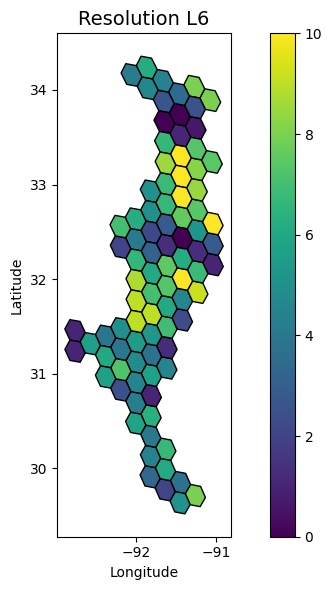

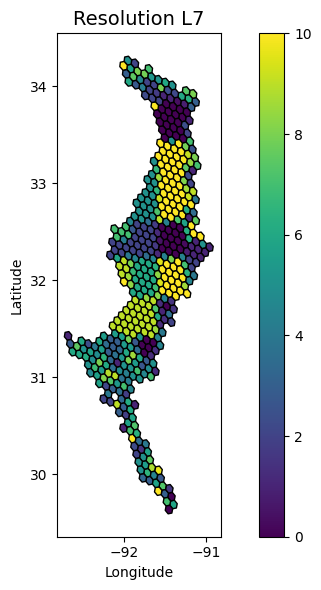

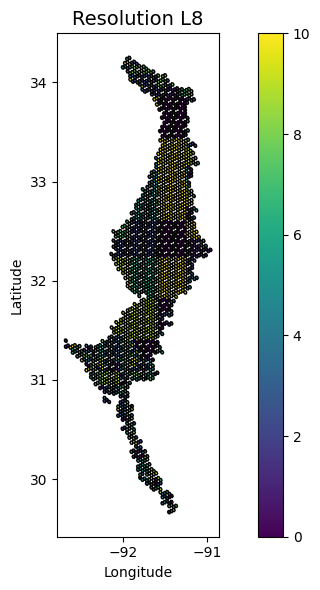

In [6]:
"""
============================================================================

Plot DGGS data

============================================================================
"""

import matplotlib.pyplot as plt

levels = ["L6", "L7", "L8"]

for level in levels:
    gdf = gpd.read_parquet(f'data/ISEA7H/{level}/LeveedArea.parquet')

    # Choropleth map
    fig, ax = plt.subplots(figsize=(8, 6))
    gdf.plot(column='cell_mean', ax=ax, edgecolor="black", cmap="viridis", legend=True)

    ax.set_title(f"Resolution {level}", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()

In [7]:
"""
============================================================================

Merge and rename columns for all resolutions into a single geoparquet file

============================================================================
"""

BASE_DIR = "data"

CONCAT_RESULT_FILE_PATH = BASE_DIR + "/ISEA7H/collection.parquet"
AGGREGATE_SEARCH_DIR_PATH = BASE_DIR + "/ISEA7H"

# columns used as ID to merge corresponding zones
# (note: if datetime-aware, should include a temporal component as well)
AGGREGATE_ZONE_ID_COLUMNS = ["dggrid_ISEA7H"]
# any column renaming (replace) to perform prior to aggregation and merging
# (note: below extended columns are affected by this change applied before)
AGGREGATE_RENAME_COLUMNS = {
    "cell_": "",
}
# columns to extend with the relevant above variable prefix (others merged as is / duplicates)
AGGREGATE_EXTEND_COLUMNS = [
    "minimum",
    "maximum",
    "mean",
    "median",
    "stddev",
]
# any 'current' containing one of the below values will be skipped
AGGREGATE_IGNORE = ["L12"]
# reorder resulting columns by specified ones first, followed by others as originally ordered
AGGREGATE_SORT_COLUMNS = AGGREGATE_ZONE_ID_COLUMNS + ["resolution", "geometry"]
# reorder zones rows according to the specified column values, in ascending(TRUE)/descending(FALSE) order
AGGREGATE_SORT_ROWS = {
    "resolution": True
}


agg_zone_total = 0
agg_zone_data = []
agg_walk_progress = os.walk(AGGREGATE_SEARCH_DIR_PATH)

for root_dir, sub_dirs, _ in agg_walk_progress:

    current = root_dir.replace(AGGREGATE_SEARCH_DIR_PATH, "").strip("/")
    if any(ignore in current for ignore in AGGREGATE_IGNORE):
        sub_dirs[:] = []  # don't recurse further
        continue

    merge_zone_data = None
    merge_zone_count = 0
    for sub_dir in sub_dirs:
        file_names = os.listdir(str(os.path.join(root_dir, sub_dir)))
        for file_name in file_names:
            if not file_name.endswith(".parquet") or file_name.startswith("dggs_zones"):
                continue
            file_path = os.path.join(root_dir, sub_dir, file_name)
            try:
                zone_data_var = gpd.read_parquet(file_path)
                zone_data_col_rename = {
                    col: col.replace(old, new)
                    for old, new in AGGREGATE_RENAME_COLUMNS.items()
                    for col in zone_data_var.columns
                }
                zone_data_var = zone_data_var.rename(columns=zone_data_col_rename)
                if merge_zone_data is None:
                    merge_zone_data = zone_data_var
                else:
                    merge_zone_data = gpd.pd.concat([merge_zone_data, zone_data_var], ignore_index=True)
                merge_zone_count = len(merge_zone_data)
                agg_zone_total += merge_zone_count
                agg_zone_msg = f"{agg_zone_total} (+{merge_zone_count})"
                break  # in case many were found, ignore others (cannot merge anyway / no priority)
            except Exception as exc:
                err_msg = f"Error while processing [{file_path}]: {exc}"
                raise Exception(err_msg) from exc

    agg_zone_data.append(merge_zone_data)
    sub_dirs[:] = []  # don't recurse further

print("Found results:", len(agg_zone_data))
agg_zone_data = gpd.pd.concat(agg_zone_data, ignore_index=True)
print("Soring results...")
if AGGREGATE_SORT_COLUMNS:
    agg_zone_cols = AGGREGATE_SORT_COLUMNS + agg_zone_data.columns.drop(AGGREGATE_SORT_COLUMNS).tolist()
    agg_zone_data = agg_zone_data.reindex(columns=agg_zone_cols)
agg_zone_sort = list(AGGREGATE_SORT_ROWS.items())
agg_zone_data = agg_zone_data.sort_values(
    by=[col for col, _ in agg_zone_sort],
    ascending=[col_asc for _, col_asc in agg_zone_sort],
)
print("Done aggregating, saving result:", CONCAT_RESULT_FILE_PATH)
agg_zone_data.to_parquet(path = CONCAT_RESULT_FILE_PATH)

Found results: 1
Soring results...
Done aggregating, saving result: data/ISEA7H/collection.parquet


In [8]:
"""
============================================================================

Create database of DGGS data

============================================================================
"""

import duckdb

con = duckdb.connect(database=':memory:')
con.execute("CREATE VIEW mydata AS SELECT * FROM read_parquet('data/ISEA7H/collection.parquet');")
con.query("SELECT dggrid_ISEA7H, resolution, minimum, maximum, mean, median, stddev, pixel_count FROM mydata WHERE mean >= 8.3 LIMIT 10;")

┌───────────────┬────────────┬─────────┬─────────┬──────────┬────────┬───────────┬─────────────┐
│ dggrid_ISEA7H │ resolution │ minimum │ maximum │   mean   │ median │  stddev   │ pixel_count │
│    varchar    │   int64    │  float  │  float  │  float   │ float  │   float   │    int64    │
├───────────────┼────────────┼─────────┼─────────┼──────────┼────────┼───────────┼─────────────┤
│ 110722        │          6 │     9.0 │     9.0 │      9.0 │    9.0 │       0.0 │           8 │
│ 111065        │          6 │     9.0 │     9.0 │      9.0 │    9.0 │       0.0 │          39 │
│ 108666        │          6 │     5.0 │    10.0 │ 8.529411 │   10.0 │ 2.2782254 │          17 │
│ 109010        │          6 │    10.0 │    10.0 │     10.0 │   10.0 │       0.0 │          52 │
│ 109353        │          6 │    10.0 │    10.0 │     10.0 │   10.0 │       0.0 │          51 │
│ 111069        │          6 │     5.0 │    10.0 │ 9.166667 │   10.0 │   1.86339 │          12 │
│ 108667        │          6 │

In [ ]:
con.query("SELECT count(*) FROM mydata WHERE mean <= 0.5;")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│          328 │
└──────────────┘

In [9]:

"""
============================================================================

Build the graph from geojson feature data

============================================================================
"""
import fiona
from shapely import within, overlaps, dwithin
from shapely.ops import nearest_points
from shapely.geometry import shape
from rdflib import Dataset, URIRef, Literal, Namespace
from rdflib.namespace import RDF, RDFS, XSD


"""
Define the in-memory graph
"""
# Define a namespace
NAMESPACE = Namespace("https://terraframe.com/example/graph")

# Create a QUAD dataset
dataset = Dataset()
# Add a triple graph to the dataset
graph = dataset.graph(URIRef(NAMESPACE + "#"))


# Create metadata about the types we want to define in the graph including: 
#   Name of type
#   The location of the data
#   Any extra feature properties we want to create triples for
tractType = {'type':'CensusTract',"location": "data/geojson/CensusTract.geojson", 'props':[{'name': 'population', 'target':"CensusTract-population", 'type': 'integer'}]}
powerType = {'type':'PowerInfrastructure', "location": "data/geojson/Power.geojson", 'props':[]}

# List of type metadata to process
nodes = [tractType, powerType]

# Create the attribute triples and add them to the graph
for nodeType in nodes:
    
    # Load the features into memory
    features = fiona.open(nodeType['location'], "r")
    
    # For power infrastructure assign the point to a DGGS cell
    if nodeType['type'] == powerType['type']:
        gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
        gdf = gdf.explode(ignore_index=True)
        
        cells = dggrid_instance.cells_for_geo_points(
            geodf_points_wgs84=gdf,
            cell_ids_only=True,
            dggs_type=validate_dggrid_type("ISEA7H"),
            resolution=7
        )       
    else :
        cells = None

    
    for feature in features:    
        
        # Define the URI for the feature and type
        id = URIRef(NAMESPACE + "#" + nodeType['type'] + '-' + feature['properties']['code'])        
        type = URIRef(NAMESPACE + "#" + nodeType['type'])
        
        # Create the code attribute  triple for the feature
        graph.add((id, URIRef(NAMESPACE + "#code"), Literal(feature['properties']['code'])))

        # Create the label attribute triple for the feature        
        graph.add((id, RDFS.label, Literal(feature['properties']['label'])))
        
        # Create the type triple for the feature                
        graph.add((id, RDF.type, type))
        
        #
        # Process the extra feature properties defined in the
        # type metadata and create attribute triples for them
        #
        for prop in nodeType['props']:
            name = URIRef(NAMESPACE + "#" + prop['target'])
            
            value = str(feature['properties'][prop['name']])
            datatype = XSD.int if prop['type'] == 'integer' else XSD.string   
            
            graph.add((id, name, Literal(value, datatype=datatype)))
            
        # Assign the DGGS zone to the power infrastructure
        if cells is not None:            
            zones = cells.loc[cells['code'] == feature['properties']['code'], 'name']
            
            graph.add((id, URIRef(NAMESPACE + "#cell"), Literal(zones.values[0])))
            
    features.close()

"""
============================================================================

Compute the edges and add them as triples

============================================================================
"""

# Find the closest power infrastructure to a tract and create a Provides power edge
with fiona.open(powerType['location'], mode='r') as pSrc:
    infrastructure = gpd.GeoDataFrame.from_features(pSrc, crs="EPSG:4326")
    
    with fiona.open(tractType['location'], mode='r') as tSrc:
        tracts = gpd.GeoDataFrame.from_features(tSrc, crs="EPSG:4326")
        
        # Perform nearest spatial join
        result = gpd.sjoin_nearest(
            tracts,
            infrastructure,            
            how="left",
            exclusive=True
        )
        result = result.sort_values(by='code_left', ascending=True)
        result = result.drop_duplicates(subset=['code_left'], keep='first')
        
        type = URIRef(NAMESPACE + "#PowerTo")
        
        for index, row in result.iterrows():
            targetId = URIRef(NAMESPACE + "#" + tractType['type'] + '-' + row['code_left'])
            sourceId = URIRef(NAMESPACE + "#" + powerType['type'] + '-' + row['code_right'])
            
            graph.add((sourceId, type, targetId))


        
""" 
Export the graph to a file
"""
print(dataset.serialize(format="trig"), file=open('data/export.trig', 'w'))

/home/jsmethie/miniconda3/envs/venv3.13/lib/python3.13/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [10]:

"""
============================================================================

Tool for querying DGGS data

============================================================================
"""
# JSON specific for the tool to be provided to OpenRouter
def get_dggs_tool_spec():
    """
    Returns the JSON Schema specification for the DGGS tool. The tool specification
    defines the input schema and describes the tool's functionality.
    For more information, see https://json-schema.org/understanding-json-schema/reference.

    :return: The tool specification for the SPARQL tool.
    """
    return {
        "type": "function",
        "function": {
            "name": "DGGS_Tool",
            "description": "Get a list of zone ids which have a water level greater than the given parameter value",
            "parameters": {
                "type": "object",
                "properties": {
                    "level": {
                        "type": "number",
                        "description": "Water level.",
                    }
                },
                "required": ["level"],
            },
        }
    }

# Implementation of the tool which executes SPARQL on the in-memory dataset
def exectue_dggs(input_data):
    """
    Returns a JSON array of zone ids.

    :param waterLevel: The water level in which to filter the DGGS zones.
    :return: JSON array of zone ids
    """
    level = input_data.get("level")

    try:        
        zones = []
        
        for row in con.query(f"SELECT dggrid_ISEA7H FROM mydata WHERE resolution = 7 AND mean <= {level} LIMIT 100;").fetchall():
            zones.append(row[0])
        
        return zones

    except Exception as e:
        return {"error": type(e), "message": str(e)}
"""
============================================================================

Compute the edges and add them as triples

============================================================================
"""
# JSON specific for the tool to be provided to OpenRouter
def get_sparql_tool_spec():
    """
    Returns the JSON Schema specification for the SPARQL tool. The tool specification
    defines the input schema and describes the tool's functionality.
    For more information, see https://json-schema.org/understanding-json-schema/reference.

    :return: The tool specification for the SPARQL tool.
    """
    return {
        "type": "function",
        "function": {
            "name": "Sparql_Tool",
            "description": "Get a result set from a triple store, based on a SPARQL select statement.",
            "parameters": {
                "type": "object",
                "properties": {
                    "statement": {
                        "type": "string",
                        "description": "SPARQL select statement.",
                    },
                },
                "required": ["statement"],
            },
        }
    }

# Implementation of the tool which executes SPARQL on the in-memory dataset
def exectue_sparql(input_data):
    """
    Executes a SPARQL statement from in an memory graphstore.
    Returns a JSON array of the results.

    :param input_data: The input data containing the SPARQL select statement.
    :return: The .
    """
    statement = input_data.get("statement")

    try:
        qres = dataset.query(statement)
    
        rows = []
        for row in qres:
            data = {}
        
            for var in qres.vars:
                data[str(var)] = str(row.get(var, ""))
            
            rows.append(data)
        
        return rows

    except Exception as e:
        return {"error": type(e), "message": str(e)}



In [11]:
# Test the SPARQL tool
statement = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>	
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX obj: <https://terraframe.com/example/graph#>

SELECT (SUM(?population) as ?totalPopulation)	
FROM <https://terraframe.com/example/graph#>
WHERE {
  ?censusTract obj:CensusTract-population ?population .	
} 
"""

input_data = {'statement': statement}

result = exectue_sparql(input_data)

json.dumps(result)

'[{"totalPopulation": "367553"}]'

In [12]:
# Test the DGGS tool
input_data = {'level': 8.3}

result = exectue_dggs(input_data)

json.dumps(result)

'["783004", "791235", "792264", "791921", "790892", "795695", "780603", "779573", "779916", "779230", "780259", "781631", "781288", "782317", "782660", "783346", "799812", "798782", "797411", "797753", "796724", "753163", "752821", "751792", "750762", "751105", "751449", "752478", "753850", "753507", "754536", "755908", "756937", "756251", "757280", "755222", "754879", "753849", "751104", "750761", "749732", "750075", "748703", "748360", "749390", "750076", "751448", "750419", "751791", "752477", "753506", "752134", "765167", "763796", "763109", "764138", "765510", "764481", "764824", "763452", "762423", "762080", "761737", "760708", "758994", "754878", "760023", "760365", "761395", "762766", "762424", "764825", "766197", "766540", "767227", "766884", "771000", "769628", "770657", "770314", "769285", "767913", "768256", "768599", "767569", "769970", "768941", "769284", "767912", "766883", "770999", "771341", "772370", "772028", "770313", "769283", "769626", "768254", "767225", "765853"

In [13]:

"""
This demo illustrates a tool use scenario using OpenRouter's Converse API and a tool to query SPRAQL.
The script interacts with a foundation model on OpenRouter and an in memory graph to provide location
information based on user input.
"""

import logging
from enum import Enum
from openrouter import OpenRouter
from classes import tool_use_print_utils as output

logging.basicConfig(level=logging.INFO, format="%(message)s")



# Define the system prompt with the instructions for the agent
SYSTEM_PROMPT = """
You are a location analysis assistant that provides location information for user-specified locations using a series of tools: 
  * DGGS_Tool - Use to get cell ids based upon criteria for water levels. 
  * Sparql_Tool - Executes SPARQL select statement to return location information. 

The user is going to ask about a location.  Use the tools defined to answer the question as best you can.  

When using the Sparql_tool use the rules below to generate a SPARQL SELECT statement for the location: 
Limit the SPARQL result set to a max of 100. 
Finally, use the Sparql_Tool to execute the SPARQL SELECT statement and return the results.  
If the respons starts with "No data found" then tell the user that you were unable to find any results for that question and to ask a different question and STOP.

Instructions:
- Use only the node types and properties provided in the schema.
- Do not use any node types and properties that are not explicitly provided.
- Include all necessary prefixes.
- Given any relationship property, you should just use them following the relationship paths provided, respecting the direction of the relationship path.

The query should follow the following guidance:
- Always generate the from clause using graph <https://terraframe.com/example/graph#>.
```
// Incorrect
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX obj: <https://terraframe.com/example/graph#>
PREFIX geo: <http://www.opengis.net/ont/geosparql#>

SELECT DISTINCT ?censusTractName
WHERE {
    ?infrastructure obj:PowerTo ?censusTract .
    ?censusTract rdfs:label ?censusTractName .
}

// Correct
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX obj: <https://terraframe.com/example/graph#>
PREFIX geo: <http://www.opengis.net/ont/geosparql#>

SELECT DISTINCT ?censusTractName
FROM <https://terraframe.com/example/graph#>
WHERE {
    ?infrastructure obj:PowerTo ?censusTract .
    ?censusTract rdfs:label ?censusTractName .
}
```

- Aggregation functions must always be wrapped in parenthesis with its variable name
```
// Incorrect
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> 
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX obj: <https://terraframe.com/example/graph#>

SELECT SUM(?population) as ?totalPopulation
FROM <https://terraframe.com/example/graph#>
WHERE {
  ?censusTract obj:GeoObject-code "CEMVK_RR_03_ONE_27" .
  ?censusTract obj:CensusTract-population ?population .  
} 

// Correct
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> 
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX obj: <https://terraframe.com/example/graph#>

SELECT (SUM(?population) as ?totalPopulation) 
FROM <https://terraframe.com/example/graph#>
WHERE {
  SELECT DISTINCT ?censusTract ?population
  WHERE {      
    ?censusTract obj:GeoObject-code "CEMVK_RR_03_ONE_27" .
    ?censusTract obj:CensusTract-population ?population .  
  }
} ```
- Aggregation functions must always restrict the values to their distinct subject
```
// Incorrect
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> 
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX obj: <https://terraframe.com/example/graph#>

SELECT (SUM(?population) as ?totalPopulation) 
FROM <https://terraframe.com/example/graph#>
WHERE {
  ?censusTract obj:GeoObject-code "CEMVK_RR_03_ONE_27" .
  ?censusTract obj:CensusTract-population ?population .  
} 

// Correct
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> 
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX obj: <https://terraframe.com/example/graph#>

SELECT (SUM(?population) as ?totalPopulation) 
FROM <https://terraframe.com/example/graph#>
WHERE {
  SELECT DISTINCT ?censusTract ?population
  WHERE {      
    ?censusTract obj:GeoObject-code "CEMVK_RR_03_ONE_27" .
    ?censusTract obj:CensusTract-population ?population .  
  }
} ```
Note: Be as concise as possible.
Do not include any explanations or apologies in your responses.
Do not include any text except the SPARQL query generated.


Schema:
In the following, each IRI is followed by the local name and optionally its description in parentheses. 
The graph supports the following node types:

<https://terraframe.com/example/graph#PowerInfrastructure> (PowerInfrastructure), 
<https://terraframe.com/example/graph#CensusTract> (CensusTract), 

The graph supports the following relationships:
<http://www.w3.org/2000/01/rdf-schema#label> - The label of the location, 
<http://www.w3.org/1999/02/22-rdf-syntax-ns#type> - The type of the location, 
<https://terraframe.com/example/graph#code> - The code of the location, 
<https://terraframe.com/example/graph#cell> - The DGGS cell of the location. Only available on School locations, 
<https://terraframe.com/example/graph#CensusTract-population> - The population of the location. Only available on CensusTract locations, 
<https://terraframe.com/example/graph#PowerTo> (PowerTo), 

The data model between types is the following:
(PowerInfrastructure)-[PowerTo]->(CensusTract)

PowerInfrastructure can be restricted by their associated DGGS zone.  You can use this data to combine the information from the DGGS_Tool
and the data generated from the Sparql_Tool.  For instance, if the user asks for a list in power infrastructure locations where the water
level is greater than 4 you should first use the DGGS_Tool to get the list of cell ids where the water level is greater than 4,
and then generate a Sparql query restricting the schools to those cell ids.  As an example, if the DGGS_Tool returns the following list
of cell ids: ["5454", "22345", "43443"], the generated Sparql statement may look like:

PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> 
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX obj: <https://terraframe.com/example/graph#>

SELECT ?label 
FROM <https://terraframe.com/example/graph#>
WHERE {
    ?infrastructure rdfs:label ?label .  
    ?infrastructure obj:cell ?cell .      
    FILTER (?cell IN ("5454", "22345", "43443"))
} 
LIMIT 100```
"""

# The maximum number of recursive calls allowed in the tool_use_demo function.
# This helps prevent infinite loops and potential performance issues.
MAX_RECURSIONS = 5


class GraphToolDemo:
    """
    Demonstrates the tool use feature with the OpenRouter Converse API.
    """

    def __init__(self):
        # Prepare the system prompt
        self.system_prompt = {"role": "system", "content": SYSTEM_PROMPT}

        # Prepare the tool configuration with the sparql tool's specification
        self.tool_config = [get_dggs_tool_spec(), get_sparql_tool_spec()]

        # Create a OpenRouter Runtime client in the specified AWS Region.
        
        self.client=OpenRouter(api_key=os.getenv("OPENROUTER_API_KEY", ""), debug_logger=logging.getLogger("openrouter"))

        
    def run(self):
        """
        Starts the conversation with the user and handles the interaction with OpenRouter.
        """
        # Print the greeting and a short user guide
        output.header()

        # Start with an emtpy conversation
        conversation = [self.system_prompt]

        # Get the first user input
        user_input = self._get_user_input()

        while user_input is not None:
            # Create a new message with the user input and append it to the conversation
            message = {"role": "user", "content": user_input}
            conversation.append(message)

            # Send the conversation to OpenRouter
            model_response = self._send_conversation(conversation)

            # Recursively handle the model's response until the model has returned
            # its final response or the recursion counter has reached 0
            self._process_model_response(
                model_response, conversation, max_recursion=MAX_RECURSIONS
            )

            # Repeat the loop until the user decides to exit the application
            user_input = self._get_user_input()

        output.footer()

    def _send_conversation(self, conversation):
        """
        Sends the conversation, the system prompt, and the tool spec to OpenRouter, and returns the response.

        :param conversation: The conversation history including the next message to send.
        :return: The response from OpenRouter.
        """
        output.remote_call(conversation)
        
        # Send the conversation, system prompt, and tool configuration, and return the response
        return  self.client.chat.send(
            messages=conversation, 
            tools=self.tool_config,
            model='anthropic/claude-4.5-sonnet',
        )

    def _process_model_response(
        self, model_response, conversation, max_recursion=MAX_RECURSIONS
    ):
        """
        Processes the response received via OpenRouter and performs the necessary actions
        based on the stop reason.

        :param model_response: The model's response returned via OpenRouter.
        :param conversation: The conversation history.
        :param max_recursion: The maximum number of recursive calls allowed.
        """

        if max_recursion <= 0:
            # Stop the process, the number of recursive calls could indicate an infinite loop
            logging.warning(
                "Warning: Maximum number of recursions reached. Please try again."
            )
            exit(1)
            

        
        if model_response.choices and model_response.choices[0]:
            
            choice = model_response.choices and model_response.choices[0]
            
            message = choice.message
            
            # Append the model's response to the ongoing conversation            
            conversation.append(message)
        
            if message.tool_calls:
                # If the stop reason is "tool_use", forward everything to the tool use handler
                self._handle_tool_use(message, conversation, max_recursion)


            if choice.finish_reason and choice.finish_reason == 'stop':
                #If the stop reason is "end_turn", print the model's response text, and finish the process
            
                if(len(message.content) > 0) :
                    output.model_response(message.content)
                else:
                    output.model_response("Agent returned an empty response")

                return

    def _handle_tool_use(
        self, model_response, conversation, max_recursion=MAX_RECURSIONS
    ):
        """
        Handles the tool use case by invoking the specified tool and sending the tool's response back to OpenRouter.
        The tool response is appended to the conversation, and the conversation is sent back to OpenRouter for further processing.

        :param model_response: The model's response containing the tool use request.
        :param conversation: The conversation history.
        :param max_recursion: The maximum number of recursive calls allowed.
        """

        # The model's response can consist of multiple content blocks
        if model_response.content:
            # If the content block contains text, print it to the console
            output.model_response(model_response.content)

        for tool_call in model_response.tool_calls:
            
            # If the content block is a tool use request, forward it to the tool
            tool_response = self._invoke_tool(tool_call)
            
            conversation.append(tool_response)
                    
        # Send the conversation to OpenRouter
        response = self._send_conversation(conversation)
        
        # Recursively handle the model's response until the model has returned
        # its final response or the recursion counter has reached 0
        self._process_model_response(response, conversation, max_recursion - 1)

    def _invoke_tool(self, payload):
        """
        Invokes the specified tool with the given payload and returns the tool's response.
        If the requested tool does not exist, an error message is returned.

        :param payload: The payload containing the tool name and input data.
        :return: The tool's response or an error message.
        """

        if payload.function and payload.function.name == "Sparql_Tool":
            
            input_data = json.loads(payload.function.arguments)
            
            output.tool_use('Sparql_Tool', input_data)

            # Invoke the sparql tool with the input data provided by
            response = exectue_sparql(input_data)
        elif payload.function and payload.function.name == "DGGS_Tool":
            
            input_data = json.loads(payload.function.arguments)
            
            output.tool_use('DGGS_Tool', input_data)

            # Invoke the DGGS tool with the input data provided by
            response = exectue_dggs(input_data)            
        else:
            error_message = (
                f"The requested tool with name '{payload.function.name}' does not exist."
            )
            response = {"error": "true", "message": error_message}

        return {"role": 'tool',  "tool_call_id": payload.id, "content": str(response)}

    @staticmethod
    def _get_user_input(prompt="Your location info request"):
        """
        Prompts the user for input and returns the user's response.
        Returns None if the user enters 'x' to exit.

        :param prompt: The prompt to display to the user.
        :return: The user's input or None if the user chooses to exit.
        """
        output.separator()
        user_input = input(f"{prompt} (x to exit): ")

        if user_input == "":
            prompt = "Please enter your location info request, e.g. the name of a location in the graph"
            return GraphToolDemo._get_user_input(prompt)

        elif user_input.lower() == "x":
            return None

        else:
            return user_input


if __name__ == "__main__":
    tool_use_demo = GraphToolDemo()
    tool_use_demo.run()




Welcome to the triple store LLM demo!
This assistant provides flood analysis for user-specified locations.
You can ask for location information by providing the location name or code and type.

Example queries:
- List 10 power infrastructure locations which are impacted when the water level is 2.5?
- What is the total population impacted when the water level is 2.5?

To exit the program, simply type 'x' and press Enter.

--------------------------------------------------------------------------------
Sending the query to the model...
[{'role': 'system', 'content': '\nYou are a location analysis assistant that provides location information for user-specified locations using a series of tools: \n  * DGGS_Tool - Use to get cell ids based upon criteria for water levels. \n  * Sparql_Tool - Executes SPARQL select statement to return location information. \n\nThe user is going to ask about a location.  Use the tools defined to answer the question as best you can.  \n\nWhen using the Sparql_